In [84]:
import numpy as np
import pandas as pd

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [85]:
df=pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [87]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [88]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [89]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [90]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

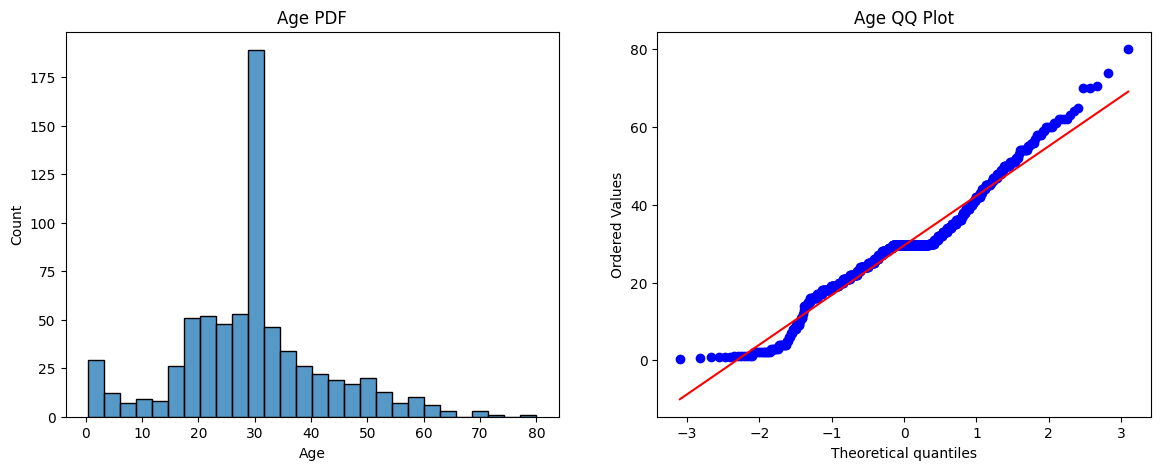

In [91]:

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

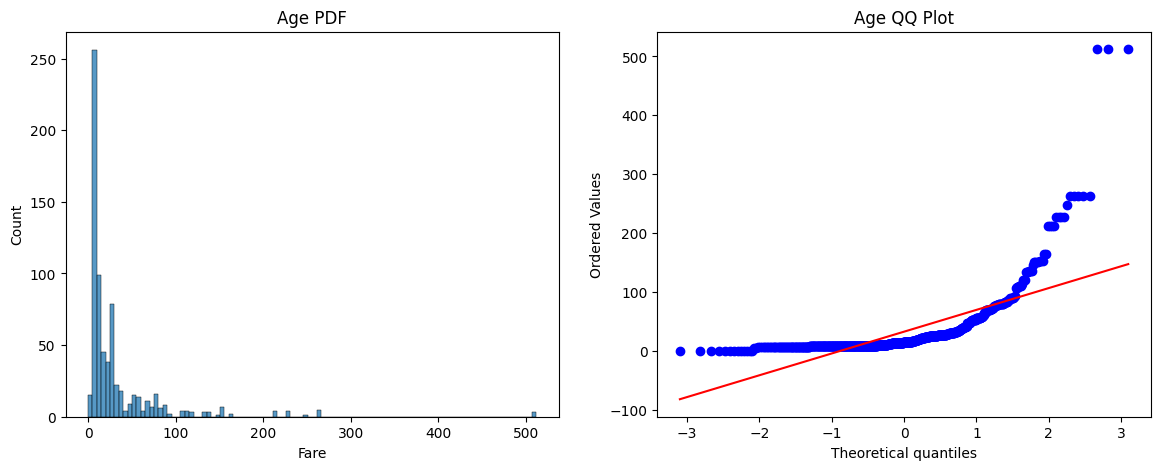

In [92]:
# right skewed
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [93]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

In [94]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf1.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6815642458100558


In [95]:
trf = FunctionTransformer(func=np.log1p)

In [96]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [97]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

clf1.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf1.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6927374301675978


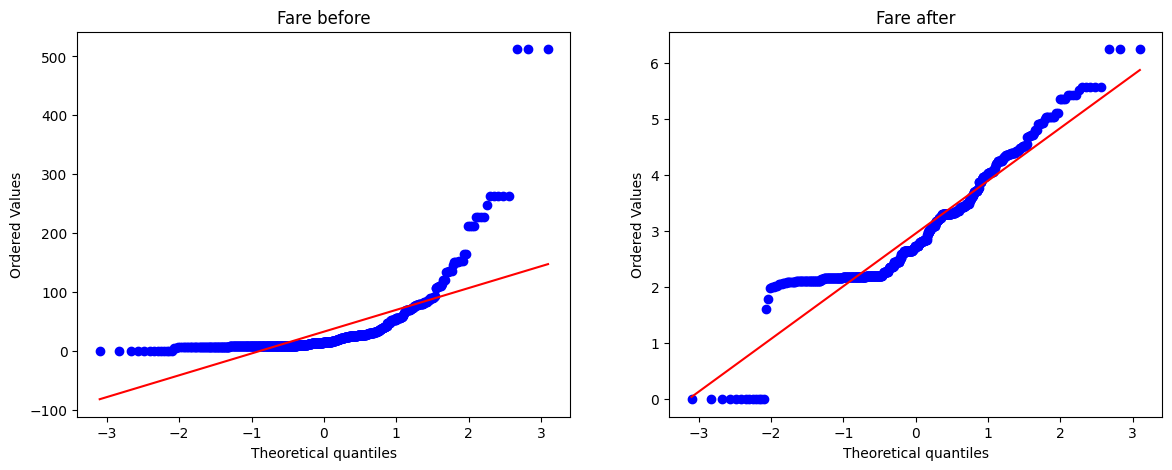

In [100]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare before')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare after')

plt.show()

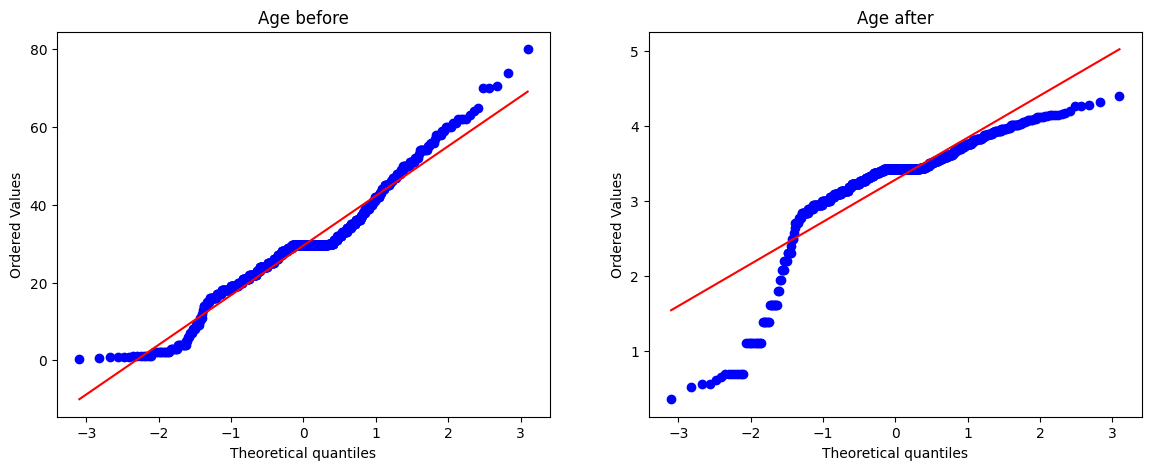

In [102]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age before')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age after')

plt.show()

In [101]:

X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6611111111111111


In [ ]:

def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(1,2,1)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(1,2,2)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.61729088639201


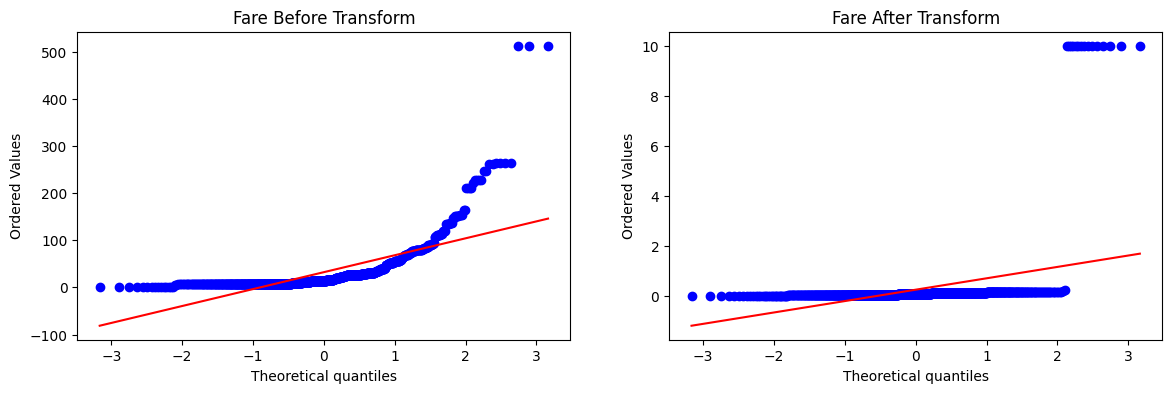

Accuracy 0.6431335830212235


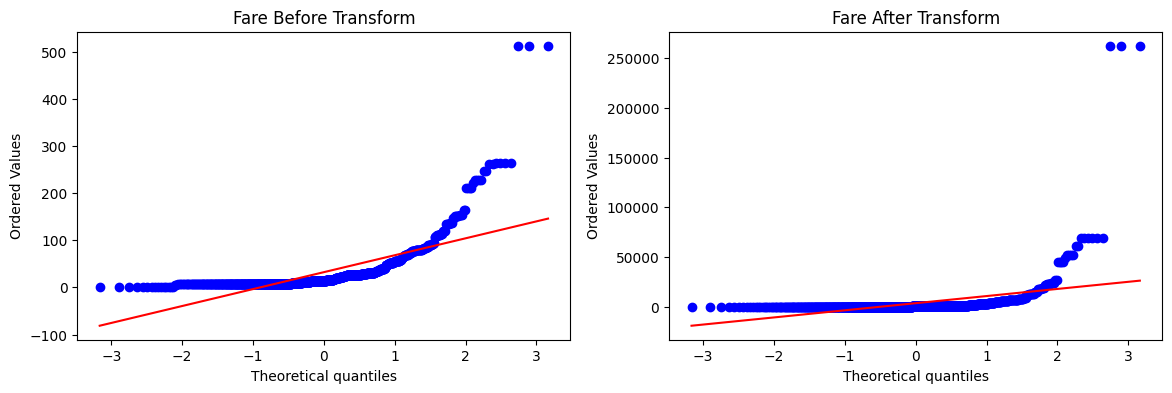

Accuracy 0.6589013732833957


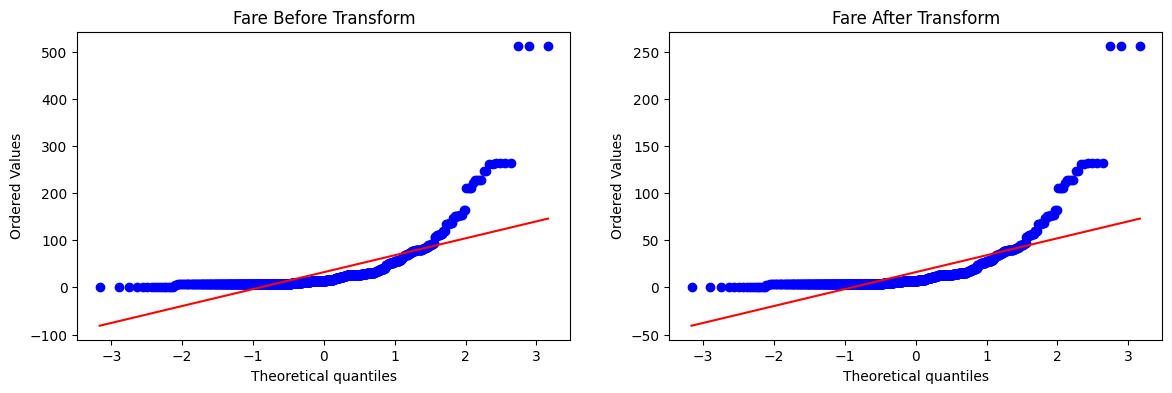

Accuracy 0.6195131086142323


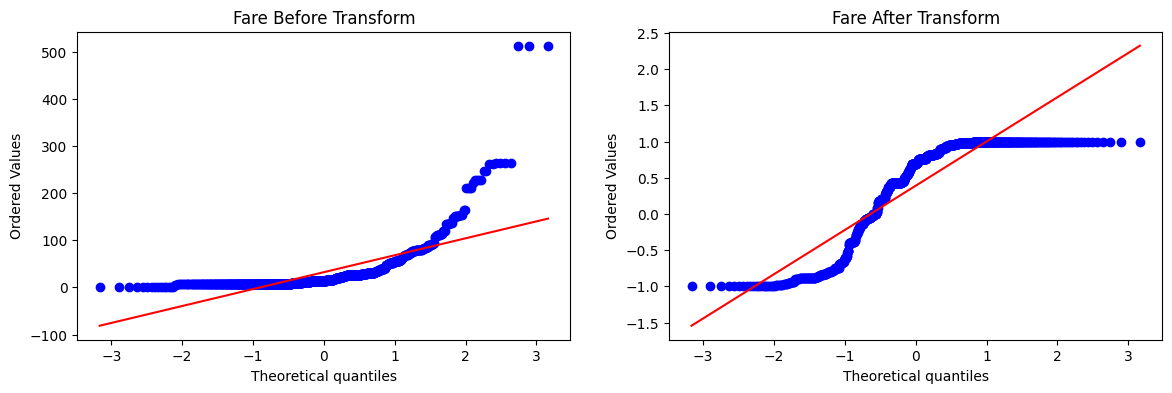

In [114]:
apply_transform(lambda x: 1/(x+0.1))
apply_transform(lambda x: x**2)
apply_transform(lambda x: x**1/2)
apply_transform(np.sin)